In [15]:
# ============================================================
# QNI-CCP EPSILON SWEEP — MALEVIS DATASET
# Tests how QNI-CCP perturbation strength (epsilon_q) affects
# Accuracy, Precision, Recall, F1 for Basic and QNI-CCP models
# Uses diff_method="backprop" → gradients flow through quantum layer
# So S is computed through the FULL path (QNN + classifier)
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import pennylane as qml
from pennylane.qnn import TorchLayer
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from tqdm import tqdm
import random
import warnings
warnings.filterwarnings("ignore")

# ── 1. CONFIGURATION ─────────────────────────────────────────────
# All values copied exactly from your Malevis training files

device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_qubits    = 10       # Malevis uses 10 qubits (not 6)
num_classes = 26       # Malevis: 25 malware families + 1 benign
batch_size  = 16

BASIC_MODEL_PATH  = "/home/netsec1/Kathan/MaleVis experiments/exp-4_1_3.pth"     # Your basic model checkpoint
QNICCP_MODEL_PATH = "qni_ccp_malevis2.pth"     # Your QNI-CCP model checkpoint
TEST_DATA_PATH    = "/home/netsec1/Kathan/MaleVis experiments/malevis_train_val_300x300/test"
TRAIN_DATA_PATH   = "/home/netsec1/Kathan/MaleVis experiments/malevis_train_val_300x300/train"
# Train loader needed only for centroid computation

# ε_q = 1/(1 + α×N_cnots + β×depth) = 1/(1 + 1×54 + 1×6) ≈ 0.0164
# N_cnots = 6 layers × 9 CNOT pairs = 54  (10 qubits → 9 pairs per layer)
# We sweep wide to see full degradation curve
QNICCP_EPSILONS = [0.0, 0.005, 0.0164, 0.03, 0.05, 0.10, 0.20, 0.30, 0.50, 0.80, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4, 5]
#                             ↑
#                   paper's ε_q ≈ 0.0164

print(f"Device      : {device}")
print(f"Qubits      : {n_qubits}  |  Classes : {num_classes}")
print(f"Paper ε_q   ≈ 0.0164  (1 / (1 + 1.0×54 + 1.0×6))")


# ── 2. QUANTUM CIRCUIT ───────────────────────────────────────────
# Copied EXACTLY from both your Malevis training files
# CRITICAL: diff_method="backprop" → gradients flow through quantum circuit
# This is different from Malimg and means S can be computed through full path

dev = qml.device("default.qubit", wires=n_qubits)   # 10-qubit quantum device

@qml.qnode(dev, interface="torch", diff_method="backprop")  # backprop = gradient-enabled
def quantum_circuit(inputs, weights):
    # Angle encoding: batch-wise inputs[..., i] encodes feature i across all batch samples
    for i in range(n_qubits):
        qml.RY(inputs[..., i], wires=i)    # inputs[..., i] supports batched input directly

    # 6 variational layers: RY rotations (trainable) + CNOT chain (entanglement)
    for l in range(weights.shape[0]):       # 6 layers
        for i in range(n_qubits):
            qml.RY(weights[l][i], wires=i)  # Trainable rotation per qubit
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])        # Linear entanglement: 9 CNOT pairs per layer

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]   # 10 measurements

weight_shapes = {"weights": (6, n_qubits)}   # 6 layers × 10 qubits = 60 quantum params


# ── 3. MODEL ARCHITECTURE ────────────────────────────────────────
# Copied EXACTLY from both your Malevis training files
# Key differences from Malimg:
#   - 6 conv blocks (not 5), last outputs 224 channels
#   - TWO FC layers: fc_expand (224→20) then fc_project (20→10)
#   - q_layer called batch-wise: self.q_layer(x) not torch.stack([self.q_layer(f) for f in x])
#   - dropout=0.1 in CNN, dropout=0.15 in classifier

class FeatureReduce(nn.Module):
    """
    CNN feature extractor for Malevis (224×224 → 10-dim latent vector).
    6 conv blocks: 1→8→16→32→64→128→224 channels.
    Two FC layers: 224→20 (expand) → 10 (project to n_qubits).
    AdaptiveAvgPool2d is INSIDE self.conv.
    tanh applied in HybridQNN.forward(), not here.
    """
    def __init__(self, final_dim, dropout=0.1):     # dropout=0.1 from your training file
        super().__init__()
        self.conv = nn.Sequential(
            # Block 1: 224×224×1 → 112×112×8
            nn.Conv2d(1, 8, 3, stride=2, padding=1),
            nn.BatchNorm2d(8), nn.ReLU(), nn.Dropout(dropout),

            # Block 2: 112×112×8 → 56×56×16
            nn.Conv2d(8, 16, 3, stride=2, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(), nn.Dropout(dropout),

            # Block 3: 56×56×16 → 28×28×32
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.Dropout(dropout),

            # Block 4: 28×28×32 → 14×14×64
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.Dropout(dropout),

            # Block 5: 14×14×64 → 7×7×128
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),

            # Block 6: 7×7×128 → 4×4×224  (larger channel count for richer representation)
            nn.Conv2d(128, 224, 3, stride=2, padding=1),
            nn.BatchNorm2d(224), nn.ReLU(),

            # Pool: 4×4×224 → 1×1×224 (inside conv, matching your training code)
            nn.AdaptiveAvgPool2d((1, 1))
        )
        # Two-stage FC: expand then project
        # fc_expand: 224→(n_qubits×2=20) — intermediary rich representation
        # fc_project: 20→n_qubits (10) — final bottleneck matching qubit count
        self.fc_expand  = nn.Linear(224, final_dim * 2)   # 224→20
        self.fc_project = nn.Linear(final_dim * 2, final_dim)   # 20→10

    def forward(self, x):
        x = self.conv(x)                    # [batch, 224, 1, 1]
        x = x.view(x.size(0), -1)          # [batch, 224]
        x = F.relu(self.fc_expand(x))      # [batch, 20] — intermediate features
        return self.fc_project(x)          # [batch, 10] — raw pre-tanh features


class HybridQNN(nn.Module):
    def __init__(self, n_qubits, num_classes):
        super().__init__()
        self.feature_extractor = FeatureReduce(final_dim=n_qubits)
        self.q_layer           = TorchLayer(quantum_circuit, weight_shapes)
        self.classifier        = nn.Sequential(
            nn.Linear(n_qubits, 64),
            nn.ReLU(), nn.Dropout(0.15),
            nn.Linear(64, 32),
            nn.ReLU(), nn.Dropout(0.15),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        x     = self.feature_extractor(x)   # CNN: [batch, 10]
        x     = torch.tanh(x)              # Squash to [-1,1] for angle encoding
        q_out = self.q_layer(x)            # QNN batch-wise: [batch, 10]
        return self.classifier(q_out)      # [batch, 26]

    def get_features(self, x):
        """
        Returns tanh-activated CNN features — the latent space z.
        Used by attack to get the starting point before perturbation.
        No gradients needed — pure feature extraction.
        """
        with torch.no_grad():
            return torch.tanh(self.feature_extractor(x))   # [batch, 10]

    def sensitivity_from_classifier(self, features, labels):
        """
        S via full quantum path (backprop enabled for Malevis).
        features has requires_grad=True — gradient flows back to features directly.
        Normalized to unit-norm so epsilon is pure step size.
            """
        # Use features and labels — matches the function signature
        q_out  = self.q_layer(features)                    # (B, 10) through quantum
        logits = self.classifier(q_out)                    # (B, 26)
        loss   = F.cross_entropy(logits, labels)           # Scalar
        loss.backward(retain_graph=True)                   # Populate features.grad
    
        if features.grad is None:
            S = torch.ones(features.size(0), features.size(1), device=features.device)
        else:
            S = features.grad.data.clone()                 # (B, 10) true gradient at features
    
        return S / (S.norm(dim=1, keepdim=True) + 1e-8)   # (B, 10) unit-norm

    def forward_from_perturbed(self, z_prime):
        """
        Forward pass from perturbed features z' through QNN + classifier.
        Skips the CNN — z' is already in feature space.
        No gradients needed — this is evaluation only.
        """
        with torch.no_grad():
            q_out  = self.q_layer(z_prime)       # [batch, 10] — quantum on perturbed z'
            return self.classifier(q_out)        # [batch, 26] — final attacked logits

# ── 4. DATASET ───────────────────────────────────────────────────

eval_transform = transforms.Compose([
    transforms.Grayscale(1),            # Grayscale (your training converts RGB→gray)
    transforms.Resize((224, 224)),      # Malevis training resolution
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_dataset  = ImageFolder(TEST_DATA_PATH,  transform=eval_transform)
train_dataset = ImageFolder(TRAIN_DATA_PATH, transform=train_transform)
# Train dataset used only for centroid computation — no augmentation needed

test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=4)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

print(f"Test  samples : {len(test_dataset)}")
print(f"Train samples : {len(train_dataset)}  (used for centroid computation)")
print(f"Classes found : {len(test_dataset.classes)}")


# ── 5. MODEL LOADING ─────────────────────────────────────────────
# Both models share the same HybridQNN class (same architecture)
# They differ only in trained weights

def load_model(path, label):
    """
    Loads HybridQNN from checkpoint.
    Both basic and QNI-CCP models use identical HybridQNN architecture.
    """
    model = HybridQNN(n_qubits=n_qubits, num_classes=num_classes).to(device)
    ckpt  = torch.load(path, map_location=device)
    # Handle both save formats
    state = ckpt['model_state_dict'] if isinstance(ckpt, dict) and 'model_state_dict' in ckpt else ckpt
    model.load_state_dict(state)
    model.eval()
    print(f"✅ Loaded [{label}] from: {path}")
    return model

basic_model  = load_model(BASIC_MODEL_PATH,  "Basic QNN")
qniccp_model = load_model(QNICCP_MODEL_PATH, "QNI-CCP QNN")


# ── 6. CENTROID COMPUTATION ──────────────────────────────────────

def compute_class_centroids(model, loader, device, num_classes, n_qubits):
    """
    Computes μ_c = mean feature vector for each class in the model's latent space.
    Uses TRAIN set (same as training) for reliable centroid positions.
    Must be computed separately for each model — their feature spaces differ
    because they were trained with different objectives.
    The centroid is the attack target: features are pushed TOWARD a wrong centroid.
    """
    model.eval()
    sums   = torch.zeros(num_classes, n_qubits, device=device)
    counts = torch.zeros(num_classes, device=device)

    with torch.no_grad():
        for x, y in tqdm(loader, desc="  Computing centroids", leave=False):
            x, y     = x.to(device), y.to(device)
            features = model.get_features(x)    # [batch, 10] tanh-activated CNN features
            for c in range(num_classes):
                mask = (y == c)
                if mask.any():
                    sums[c]   += features[mask].sum(0)
                    counts[c] += mask.sum()

    counts[counts == 0] = 1
    return sums / counts.unsqueeze(1)   # [26, 10] — one centroid per class


# ── 7. QNI-CCP ATTACK ────────────────────────────────────────────

# In HybridQNN class — replace sensitivity_through_full_path with this:




# Replace qni_ccp_attack with this — only S computation method name changes:

def qni_ccp_attack(model, images, labels, epsilon_q, centroids):
    """
    QNI-CCP attack with normalized S.
    S normalization ensures ε_q directly controls perturbation strength
    regardless of gradient magnitude issues in the quantum layer.
    z' = z + ε_q · [S_hat ⊙ (μ_c' − z)]
    """
    if epsilon_q == 0.0:
        with torch.no_grad():
            return model(images)

    model.eval()

    # Step 1: Clean features
    original_features = model.get_features(images)   # [batch, 10]

    # Step 2: Normalized classifier sensitivity
    features_for_grad = original_features.clone().detach().requires_grad_(True)
    S = model.sensitivity_from_classifier(features_for_grad, labels)
    # S is now a unit-norm direction per sample — ε_q controls magnitude directly

    # Step 3: Wrong-class centroid
    target_classes = []
    for i in range(labels.size(0)):
        available = [c for c in range(centroids.size(0)) if c != labels[i].item()]
        target_classes.append(
            random.choice(available) if available
            else (labels[i].item() + 1) % centroids.size(0)
        )
    target_tensor = torch.tensor(target_classes, device=device)
    mu_c_prime    = centroids[target_tensor]   # [batch, 10]

    # Step 4: Normalized direction toward wrong centroid
    direction     = mu_c_prime - original_features             # [batch, 10]
    dir_norm      = direction / (direction.norm(dim=1, keepdim=True) + 1e-8)
    # Normalize direction too — so ε_q is purely a step-size parameter
    # Without this: classes with far centroids get stronger perturbation
    # than close ones, making results dependent on centroid geometry

    weighted      = S * dir_norm                               # [batch, 10]
    z_prime       = original_features + epsilon_q * weighted   # [batch, 10]

    # Step 5: Forward from perturbed features
    return model.forward_from_perturbed(z_prime)   # [batch, 26]

# ── 8. EVALUATION FUNCTION ───────────────────────────────────────

def evaluate_qniccp_epsilon(model, loader, centroids, epsilon_q, label):
    """
    Evaluates model under QNI-CCP at a specific epsilon_q.
    Macro averaging used — treats all 26 classes equally.
    Important for Malevis which has balanced classes (400-500 per class).
    """
    model.eval()
    all_preds  = []
    all_labels = []

    for images, labels in tqdm(loader, desc=f"  ε_q={epsilon_q:.4f} | {label}", leave=False):
        images, labels = images.to(device), labels.to(device)

        logits = qni_ccp_attack(model, images, labels, epsilon_q, centroids)
        preds  = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    rec  = recall_score(all_labels, all_preds,    average='macro', zero_division=0)
    f1   = f1_score(all_labels, all_preds,        average='macro', zero_division=0)

    return acc, prec, rec, f1


# ── 9. COMPUTE CENTROIDS ─────────────────────────────────────────
# Use train set (matches what was used during QNI-CCP training)

print("\nComputing centroids for Basic model...")
centroids_basic  = compute_class_centroids(basic_model,  train_loader, device, num_classes, n_qubits)

print("Computing centroids for QNI-CCP model...")
centroids_qniccp = compute_class_centroids(qniccp_model, train_loader, device, num_classes, n_qubits)

print("✅ Centroids ready.\n")


# ── 10. EPSILON SWEEP ────────────────────────────────────────────

results = {
    "Basic"  : {"acc": [], "prec": [], "rec": [], "f1": []},
    "QNICCP" : {"acc": [], "prec": [], "rec": [], "f1": []},
}

print("═"*65)
print("  QNI-CCP EPSILON SWEEP — MALEVIS DATASET")
print("═"*65)

for eps in QNICCP_EPSILONS:
    print(f"\n[QNI-CCP] ε_q = {eps:.4f}")

    acc, prec, rec, f1 = evaluate_qniccp_epsilon(
        basic_model, test_loader, centroids_basic, eps, "Basic"
    )
    results["Basic"]["acc"].append(acc)
    results["Basic"]["prec"].append(prec)
    results["Basic"]["rec"].append(rec)
    results["Basic"]["f1"].append(f1)
    print(f"  Basic   | Acc: {acc:.4f}  Prec: {prec:.4f}  Rec: {rec:.4f}  F1: {f1:.4f}")

    acc, prec, rec, f1 = evaluate_qniccp_epsilon(
        qniccp_model, test_loader, centroids_qniccp, eps, "QNI-CCP"
    )
    results["QNICCP"]["acc"].append(acc)
    results["QNICCP"]["prec"].append(prec)
    results["QNICCP"]["rec"].append(rec)
    results["QNICCP"]["f1"].append(f1)
    print(f"  QNI-CCP | Acc: {acc:.4f}  Prec: {prec:.4f}  Rec: {rec:.4f}  F1: {f1:.4f}")


# ── 11. SUMMARY TABLE ────────────────────────────────────────────

print(f"\n{'═'*80}")
print(f"  SUMMARY — QNI-CCP ε_q SWEEP  |  Malevis Dataset")
print(f"{'═'*80}")
print(f"  {'ε_q':>7}   {'Basic Acc':>9} {'QNI Acc':>9}   {'Basic F1':>9} {'QNI F1':>9}   {'Δ Acc':>8} {'Δ F1':>8}")
print(f"  {'─'*75}")

for i, eps in enumerate(QNICCP_EPSILONS):
    b_acc = results["Basic"]["acc"][i]
    q_acc = results["QNICCP"]["acc"][i]
    b_f1  = results["Basic"]["f1"][i]
    q_f1  = results["QNICCP"]["f1"][i]
    d_acc = q_acc - b_acc
    d_f1  = q_f1  - b_f1
    a_acc = "↑" if d_acc >= 0 else "↓"
    a_f1  = "↑" if d_f1  >= 0 else "↓"
    marker = " ◄ paper ε_q" if abs(eps - 0.0164) < 1e-4 else ""
    print(f"  {eps:>7.4f}   {b_acc:>9.4f} {q_acc:>9.4f}   {b_f1:>9.4f} {q_f1:>9.4f}   "
          f"{d_acc:>+7.4f}{a_acc} {d_f1:>+7.4f}{a_f1}{marker}")


# ── 12. PLOTS ─────────────────────────────────────────────────────

metrics      = ["acc",       "prec",       "rec",      "f1"]
metric_names = ["Accuracy",  "Precision",  "Recall",   "F1-Score (Macro)"]
colors       = {"Basic": "#E74C3C", "QNICCP": "#2980B9"}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "QNI-CCP ε_q Sweep: Basic QNN vs QNI-CCP — Malevis Dataset\n"
    "Latent-space perturbation strength vs classification performance",
    fontsize=13, fontweight='bold'
)
axes = axes.flatten()

for idx, (metric, mname) in enumerate(zip(metrics, metric_names)):
    ax         = axes[idx]
    basic_vals = results["Basic"][metric]
    qni_vals   = results["QNICCP"][metric]

    ax.plot(QNICCP_EPSILONS, basic_vals, marker='o', color=colors["Basic"],
            label='Basic QNN', linewidth=2, markersize=6)
    ax.plot(QNICCP_EPSILONS, qni_vals,   marker='s', color=colors["QNICCP"],
            label='QNI-CCP',   linewidth=2, markersize=6, linestyle='--')

    # Mark paper's ε_q
    ax.axvline(x=0.0164, color='gray', linestyle=':', linewidth=1.5,
               label='Paper ε_q≈0.0164')

    # Shade gap between curves
    ax.fill_between(QNICCP_EPSILONS, basic_vals, qni_vals,
                    alpha=0.08, color='green', label='Robustness gap')

    ax.set_title(mname, fontsize=11, fontweight='bold')
    ax.set_xlabel("QNI-CCP Epsilon (ε_q)", fontsize=9)
    ax.set_ylabel(mname, fontsize=9)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8, loc='lower left')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(QNICCP_EPSILONS)
    ax.tick_params(axis='x', rotation=45, labelsize=7)

plt.tight_layout()
plt.savefig("qniccp_epsilon_sweep_malevis.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved: qniccp_epsilon_sweep_malevis.png")


# ── 13. SAVE RESULTS ──────────────────────────────────────────────

with open("qniccp_epsilon_sweep_malevis_results.txt", "w") as f:
    f.write("QNI-CCP EPSILON SWEEP RESULTS — MALEVIS DATASET\n")
    f.write("="*80 + "\n\n")
    f.write(f"{'eps_q':>7}  {'Model':>10}  {'Accuracy':>10} {'Precision':>10} "
            f"{'Recall':>10} {'F1':>10}\n")
    f.write("-"*65 + "\n")
    for i, eps in enumerate(QNICCP_EPSILONS):
        for key, lbl in [("Basic", "Basic"), ("QNICCP", "QNI-CCP")]:
            f.write(f"{eps:>7.4f}  {lbl:>10}  "
                    f"{results[key]['acc'][i]:>10.4f} "
                    f"{results[key]['prec'][i]:>10.4f} "
                    f"{results[key]['rec'][i]:>10.4f} "
                    f"{results[key]['f1'][i]:>10.4f}\n")

print("✅ Results saved: qniccp_epsilon_sweep_malevis_results.txt")

Device      : cuda
Qubits      : 10  |  Classes : 26
Paper ε_q   ≈ 0.0164  (1 / (1 + 1.0×54 + 1.0×6))
Test  samples : 2130
Train samples : 9947  (used for centroid computation)
Classes found : 26
✅ Loaded [Basic QNN] from: /home/netsec1/Kathan/MaleVis experiments/exp-4_1_3.pth
✅ Loaded [QNI-CCP QNN] from: qni_ccp_malevis2.pth

Computing centroids for Basic model...


Computing centroids for QNI-CCP model...


KeyboardInterrupt: 

Device      : cuda
Qubits      : 10  |  Classes : 26
Paper ε_q   ≈ 0.0164  (1 / (1 + 1.0×54 + 1.0×6))
Test  samples : 2130
Train samples : 9947  (used for centroid computation)
Classes found : 26
✅ Loaded [Basic QNN] from: /home/netsec1/Kathan/MaleVis experiments/exp-4_1_3.pth
✅ Loaded [QNI-CCP QNN] from: qni_ccp_malevis2.pth

Computing centroids for Basic model...


Computing centroids for QNI-CCP model...


✅ Centroids ready.

═════════════════════════════════════════════════════════════════
  QNI-CCP EPSILON SWEEP — MALEVIS DATASET
═════════════════════════════════════════════════════════════════

[QNI-CCP] ε_q = 0.0000


  Basic   | Acc: 0.8005  Prec: 0.8617  Rec: 0.8889  F1: 0.8660


  QNI-CCP | Acc: 0.8986  Prec: 0.9003  Rec: 0.9322  F1: 0.9132

[QNI-CCP] ε_q = 0.0050


...

  QNI-CCP | Acc: 0.5488  Prec: 0.5431  Rec: 0.5635  F1: 0.5357

[QNI-CCP] ε_q = 4.0000


  Basic   | Acc: 0.2582  Prec: 0.2710  Rec: 0.2921  F1: 0.2657


  QNI-CCP | Acc: 0.4676  Prec: 0.4631  Rec: 0.4807  F1: 0.4511

[QNI-CCP] ε_q = 5.0000


  Basic   | Acc: 0.1897  Prec: 0.2050  Rec: 0.2103  F1: 0.1903


  QNI-CCP | Acc: 0.3535  Prec: 0.3647  Rec: 0.3610  F1: 0.3398

════════════════════════════════════════════════════════════════════════════════
  SUMMARY — QNI-CCP ε_q SWEEP  |  Malevis Dataset
════════════════════════════════════════════════════════════════════════════════
      ε_q   Basic Acc   QNI Acc    Basic F1    QNI F1      Δ Acc     Δ F1
  ───────────────────────────────────────────────────────────────────────────
   0.0000      0.8005    0.8986      0.8660    0.9132   +0.0981↑ +0.0472↑
   0.0050      0.8005    0.8991      0.8665    0.9134   +0.0986↑ +0.0469↑
   0.0164      0.8028    0.8991      0.8685    0.9137   +0.0962↑ +0.0452↑ ◄ paper ε_q
   0.0300      0.8038    0.8986      0.8692    0.9132   +0.0948↑ +0.0440↑
   0.0500      0.8066    0.8986      0.8700    0.9135   +0.0920↑ +0.0435↑
   0.1000      0.8042    0.9009      0.8696    0.9147   +0.0967↑ +0.0451↑
   0.2000      0.8052    0.9009      0.8641    0.9145   +0.0958↑ +0.0504↑
   0.3000      0.8066    0.8995      0.862

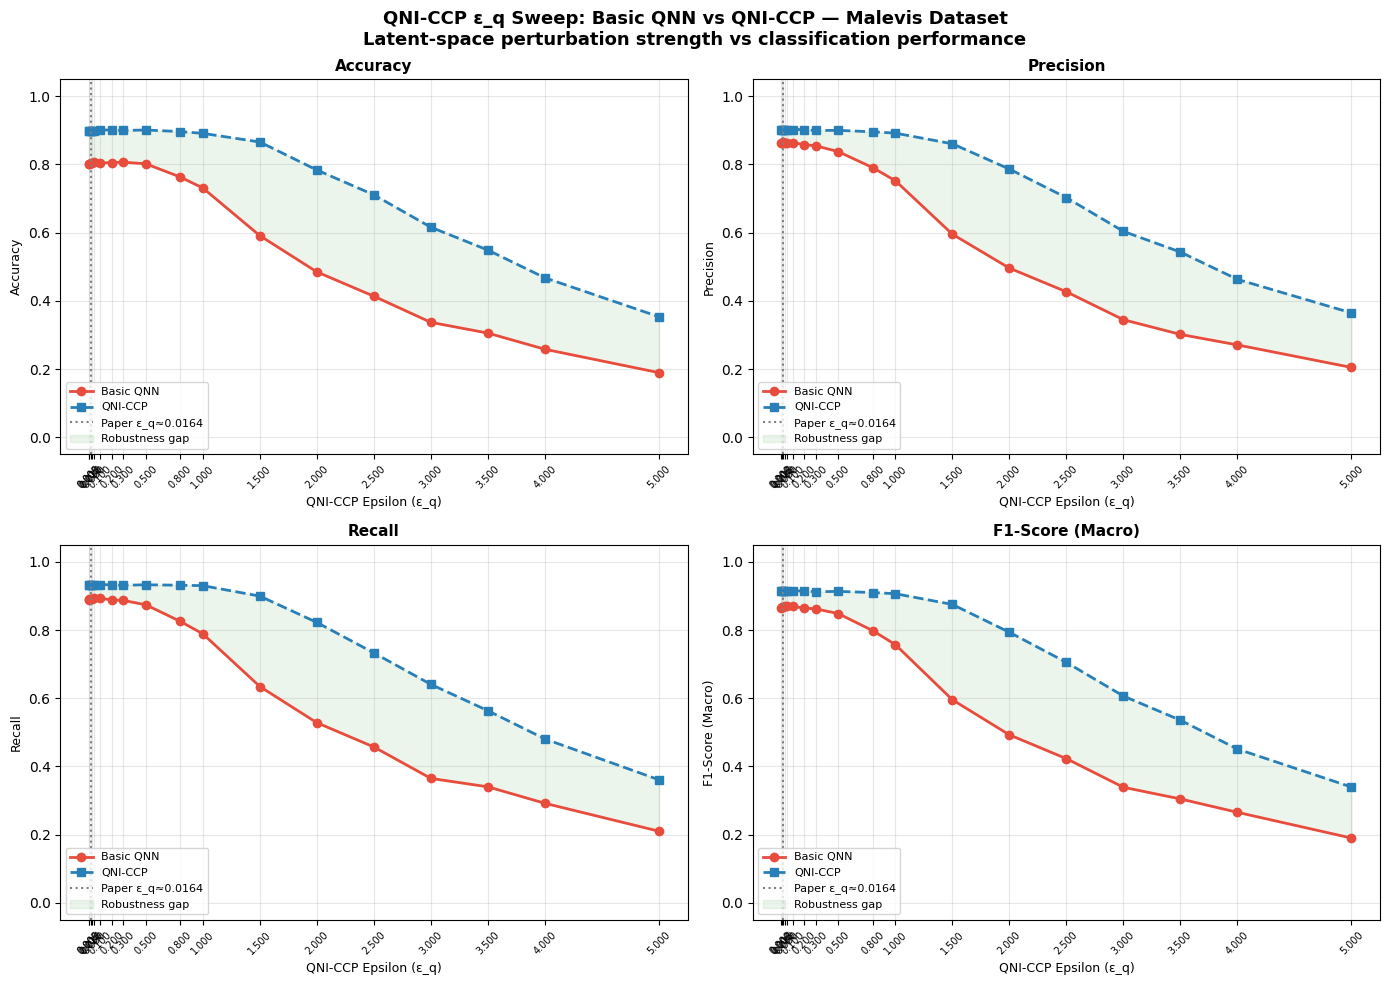

✅ Plot saved: qniccp_epsilon_sweep_malevis.png
✅ Results saved: qniccp_epsilon_sweep_malevis_results.txt


In [16]:
# ============================================================
# QNI-CCP EPSILON SWEEP — MALEVIS DATASET
# Tests how QNI-CCP perturbation strength (epsilon_q) affects
# Accuracy, Precision, Recall, F1 for Basic and QNI-CCP models
# Uses diff_method="backprop" → gradients flow through quantum layer
# So S is computed through the FULL path (QNN + classifier)
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import pennylane as qml
from pennylane.qnn import TorchLayer
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from tqdm import tqdm
import random
import warnings
warnings.filterwarnings("ignore")

# ── 1. CONFIGURATION ─────────────────────────────────────────────
# All values copied exactly from your Malevis training files

device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_qubits    = 10       # Malevis uses 10 qubits (not 6)
num_classes = 26       # Malevis: 25 malware families + 1 benign
batch_size  = 16

BASIC_MODEL_PATH  = "/home/netsec1/Kathan/MaleVis experiments/exp-4_1_3.pth"     # Your basic model checkpoint
QNICCP_MODEL_PATH = "qni_ccp_malevis2.pth"     # Your QNI-CCP model checkpoint
TEST_DATA_PATH    = "/home/netsec1/Kathan/MaleVis experiments/malevis_train_val_300x300/test"
TRAIN_DATA_PATH   = "/home/netsec1/Kathan/MaleVis experiments/malevis_train_val_300x300/train"
# Train loader needed only for centroid computation

# ε_q = 1/(1 + α×N_cnots + β×depth) = 1/(1 + 1×54 + 1×6) ≈ 0.0164
# N_cnots = 6 layers × 9 CNOT pairs = 54  (10 qubits → 9 pairs per layer)
# We sweep wide to see full degradation curve
QNICCP_EPSILONS = [0.0, 0.005, 0.0164, 0.03, 0.05, 0.10, 0.20, 0.30, 0.50, 0.80, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4, 5]
#                             ↑
#                   paper's ε_q ≈ 0.0164

print(f"Device      : {device}")
print(f"Qubits      : {n_qubits}  |  Classes : {num_classes}")
print(f"Paper ε_q   ≈ 0.0164  (1 / (1 + 1.0×54 + 1.0×6))")


# ── 2. QUANTUM CIRCUIT ───────────────────────────────────────────
# Copied EXACTLY from both your Malevis training files
# CRITICAL: diff_method="backprop" → gradients flow through quantum circuit
# This is different from Malimg and means S can be computed through full path

dev = qml.device("default.qubit", wires=n_qubits)   # 10-qubit quantum device

@qml.qnode(dev, interface="torch", diff_method="backprop")  # backprop = gradient-enabled
def quantum_circuit(inputs, weights):
    # Angle encoding: batch-wise inputs[..., i] encodes feature i across all batch samples
    for i in range(n_qubits):
        qml.RY(inputs[..., i], wires=i)    # inputs[..., i] supports batched input directly

    # 6 variational layers: RY rotations (trainable) + CNOT chain (entanglement)
    for l in range(weights.shape[0]):       # 6 layers
        for i in range(n_qubits):
            qml.RY(weights[l][i], wires=i)  # Trainable rotation per qubit
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])        # Linear entanglement: 9 CNOT pairs per layer

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]   # 10 measurements

weight_shapes = {"weights": (6, n_qubits)}   # 6 layers × 10 qubits = 60 quantum params


# ── 3. MODEL ARCHITECTURE ────────────────────────────────────────
# Copied EXACTLY from both your Malevis training files
# Key differences from Malimg:
#   - 6 conv blocks (not 5), last outputs 224 channels
#   - TWO FC layers: fc_expand (224→20) then fc_project (20→10)
#   - q_layer called batch-wise: self.q_layer(x) not torch.stack([self.q_layer(f) for f in x])
#   - dropout=0.1 in CNN, dropout=0.15 in classifier

class FeatureReduce(nn.Module):
    """
    CNN feature extractor for Malevis (224×224 → 10-dim latent vector).
    6 conv blocks: 1→8→16→32→64→128→224 channels.
    Two FC layers: 224→20 (expand) → 10 (project to n_qubits).
    AdaptiveAvgPool2d is INSIDE self.conv.
    tanh applied in HybridQNN.forward(), not here.
    """
    def __init__(self, final_dim, dropout=0.1):     # dropout=0.1 from your training file
        super().__init__()
        self.conv = nn.Sequential(
            # Block 1: 224×224×1 → 112×112×8
            nn.Conv2d(1, 8, 3, stride=2, padding=1),
            nn.BatchNorm2d(8), nn.ReLU(), nn.Dropout(dropout),

            # Block 2: 112×112×8 → 56×56×16
            nn.Conv2d(8, 16, 3, stride=2, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(), nn.Dropout(dropout),

            # Block 3: 56×56×16 → 28×28×32
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.Dropout(dropout),

            # Block 4: 28×28×32 → 14×14×64
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.Dropout(dropout),

            # Block 5: 14×14×64 → 7×7×128
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),

            # Block 6: 7×7×128 → 4×4×224  (larger channel count for richer representation)
            nn.Conv2d(128, 224, 3, stride=2, padding=1),
            nn.BatchNorm2d(224), nn.ReLU(),

            # Pool: 4×4×224 → 1×1×224 (inside conv, matching your training code)
            nn.AdaptiveAvgPool2d((1, 1))
        )
        # Two-stage FC: expand then project
        # fc_expand: 224→(n_qubits×2=20) — intermediary rich representation
        # fc_project: 20→n_qubits (10) — final bottleneck matching qubit count
        self.fc_expand  = nn.Linear(224, final_dim * 2)   # 224→20
        self.fc_project = nn.Linear(final_dim * 2, final_dim)   # 20→10

    def forward(self, x):
        x = self.conv(x)                    # [batch, 224, 1, 1]
        x = x.view(x.size(0), -1)          # [batch, 224]
        x = F.relu(self.fc_expand(x))      # [batch, 20] — intermediate features
        return self.fc_project(x)          # [batch, 10] — raw pre-tanh features


class HybridQNN(nn.Module):
    def __init__(self, n_qubits, num_classes):
        super().__init__()
        self.feature_extractor = FeatureReduce(final_dim=n_qubits)
        self.q_layer           = TorchLayer(quantum_circuit, weight_shapes)
        self.classifier        = nn.Sequential(
            nn.Linear(n_qubits, 64),
            nn.ReLU(), nn.Dropout(0.15),
            nn.Linear(64, 32),
            nn.ReLU(), nn.Dropout(0.15),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        x     = self.feature_extractor(x)   # CNN: [batch, 10]
        x     = torch.tanh(x)              # Squash to [-1,1] for angle encoding
        q_out = self.q_layer(x)            # QNN batch-wise: [batch, 10]
        return self.classifier(q_out)      # [batch, 26]

    def get_features(self, x):
        """
        Returns tanh-activated CNN features — the latent space z.
        Used by attack to get the starting point before perturbation.
        No gradients needed — pure feature extraction.
        """
        with torch.no_grad():
            return torch.tanh(self.feature_extractor(x))   # [batch, 10]

    def sensitivity_from_classifier(self, features, labels):
        """
        S via full quantum path (backprop enabled for Malevis).
        features has requires_grad=True — gradient flows back to features directly.
        Normalized to unit-norm so epsilon is pure step size.
            """
        # Use features and labels — matches the function signature
        q_out  = self.q_layer(features)                    # (B, 10) through quantum
        logits = self.classifier(q_out)                    # (B, 26)
        loss   = F.cross_entropy(logits, labels)           # Scalar
        loss.backward(retain_graph=True)                   # Populate features.grad
    
        if features.grad is None:
            S = torch.ones(features.size(0), features.size(1), device=features.device)
        else:
            S = features.grad.data.clone()                 # (B, 10) true gradient at features
    
        return S / (S.norm(dim=1, keepdim=True) + 1e-8)   # (B, 10) unit-norm

    def forward_from_perturbed(self, z_prime):
        """
        Forward pass from perturbed features z' through QNN + classifier.
        Skips the CNN — z' is already in feature space.
        No gradients needed — this is evaluation only.
        """
        with torch.no_grad():
            q_out  = self.q_layer(z_prime)       # [batch, 10] — quantum on perturbed z'
            return self.classifier(q_out)        # [batch, 26] — final attacked logits

# ── 4. DATASET ───────────────────────────────────────────────────

eval_transform = transforms.Compose([
    transforms.Grayscale(1),            # Grayscale (your training converts RGB→gray)
    transforms.Resize((224, 224)),      # Malevis training resolution
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_dataset  = ImageFolder(TEST_DATA_PATH,  transform=eval_transform)
train_dataset = ImageFolder(TRAIN_DATA_PATH, transform=train_transform)
# Train dataset used only for centroid computation — no augmentation needed

test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=4)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

print(f"Test  samples : {len(test_dataset)}")
print(f"Train samples : {len(train_dataset)}  (used for centroid computation)")
print(f"Classes found : {len(test_dataset.classes)}")


# ── 5. MODEL LOADING ─────────────────────────────────────────────
# Both models share the same HybridQNN class (same architecture)
# They differ only in trained weights

def load_model(path, label):
    """
    Loads HybridQNN from checkpoint.
    Both basic and QNI-CCP models use identical HybridQNN architecture.
    """
    model = HybridQNN(n_qubits=n_qubits, num_classes=num_classes).to(device)
    ckpt  = torch.load(path, map_location=device)
    # Handle both save formats
    state = ckpt['model_state_dict'] if isinstance(ckpt, dict) and 'model_state_dict' in ckpt else ckpt
    model.load_state_dict(state)
    model.eval()
    print(f"✅ Loaded [{label}] from: {path}")
    return model

basic_model  = load_model(BASIC_MODEL_PATH,  "Basic QNN")
qniccp_model = load_model(QNICCP_MODEL_PATH, "QNI-CCP QNN")


# ── 6. CENTROID COMPUTATION ──────────────────────────────────────

def compute_class_centroids(model, loader, device, num_classes, n_qubits):
    """
    Computes μ_c = mean feature vector for each class in the model's latent space.
    Uses TRAIN set (same as training) for reliable centroid positions.
    Must be computed separately for each model — their feature spaces differ
    because they were trained with different objectives.
    The centroid is the attack target: features are pushed TOWARD a wrong centroid.
    """
    model.eval()
    sums   = torch.zeros(num_classes, n_qubits, device=device)
    counts = torch.zeros(num_classes, device=device)

    with torch.no_grad():
        for x, y in tqdm(loader, desc="  Computing centroids", leave=False):
            x, y     = x.to(device), y.to(device)
            features = model.get_features(x)    # [batch, 10] tanh-activated CNN features
            for c in range(num_classes):
                mask = (y == c)
                if mask.any():
                    sums[c]   += features[mask].sum(0)
                    counts[c] += mask.sum()

    counts[counts == 0] = 1
    return sums / counts.unsqueeze(1)   # [26, 10] — one centroid per class


# ── 7. QNI-CCP ATTACK ────────────────────────────────────────────

# In HybridQNN class — replace sensitivity_through_full_path with this:




# Replace qni_ccp_attack with this — only S computation method name changes:

def qni_ccp_attack(model, images, labels, epsilon_q, centroids):
    """
    QNI-CCP attack with normalized S.
    S normalization ensures ε_q directly controls perturbation strength
    regardless of gradient magnitude issues in the quantum layer.
    z' = z + ε_q · [S_hat ⊙ (μ_c' − z)]
    """
    if epsilon_q == 0.0:
        with torch.no_grad():
            return model(images)

    model.eval()

    # Step 1: Clean features
    original_features = model.get_features(images)   # [batch, 10]

    # Step 2: Normalized classifier sensitivity
    features_for_grad = original_features.clone().detach().requires_grad_(True)
    S = model.sensitivity_from_classifier(features_for_grad, labels)
    # S is now a unit-norm direction per sample — ε_q controls magnitude directly

    # Step 3: Wrong-class centroid
    target_classes = []
    for i in range(labels.size(0)):
        available = [c for c in range(centroids.size(0)) if c != labels[i].item()]
        target_classes.append(
            random.choice(available) if available
            else (labels[i].item() + 1) % centroids.size(0)
        )
    target_tensor = torch.tensor(target_classes, device=device)
    mu_c_prime    = centroids[target_tensor]   # [batch, 10]

    # Step 4: Normalized direction toward wrong centroid
    direction     = mu_c_prime - original_features             # [batch, 10]
    dir_norm      = direction / (direction.norm(dim=1, keepdim=True) + 1e-8)
    # Normalize direction too — so ε_q is purely a step-size parameter
    # Without this: classes with far centroids get stronger perturbation
    # than close ones, making results dependent on centroid geometry

    weighted      = S * dir_norm                               # [batch, 10]
    z_prime       = original_features + epsilon_q * weighted   # [batch, 10]

    # Step 5: Forward from perturbed features
    return model.forward_from_perturbed(z_prime)   # [batch, 26]

# ── 8. EVALUATION FUNCTION ───────────────────────────────────────

def evaluate_qniccp_epsilon(model, loader, centroids, epsilon_q, label):
    """
    Evaluates model under QNI-CCP at a specific epsilon_q.
    Macro averaging used — treats all 26 classes equally.
    Important for Malevis which has balanced classes (400-500 per class).
    """
    model.eval()
    all_preds  = []
    all_labels = []

    for images, labels in tqdm(loader, desc=f"  ε_q={epsilon_q:.4f} | {label}", leave=False):
        images, labels = images.to(device), labels.to(device)

        logits = qni_ccp_attack(model, images, labels, epsilon_q, centroids)
        preds  = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    rec  = recall_score(all_labels, all_preds,    average='macro', zero_division=0)
    f1   = f1_score(all_labels, all_preds,        average='macro', zero_division=0)

    return acc, prec, rec, f1


# ── 9. COMPUTE CENTROIDS ─────────────────────────────────────────
# Use train set (matches what was used during QNI-CCP training)

print("\nComputing centroids for Basic model...")
centroids_basic  = compute_class_centroids(basic_model,  train_loader, device, num_classes, n_qubits)

print("Computing centroids for QNI-CCP model...")
centroids_qniccp = compute_class_centroids(qniccp_model, train_loader, device, num_classes, n_qubits)

print("✅ Centroids ready.\n")


# ── 10. EPSILON SWEEP ────────────────────────────────────────────

results = {
    "Basic"  : {"acc": [], "prec": [], "rec": [], "f1": []},
    "QNICCP" : {"acc": [], "prec": [], "rec": [], "f1": []},
}

print("═"*65)
print("  QNI-CCP EPSILON SWEEP — MALEVIS DATASET")
print("═"*65)

for eps in QNICCP_EPSILONS:
    print(f"\n[QNI-CCP] ε_q = {eps:.4f}")

    acc, prec, rec, f1 = evaluate_qniccp_epsilon(
        basic_model, test_loader, centroids_basic, eps, "Basic"
    )
    results["Basic"]["acc"].append(acc)
    results["Basic"]["prec"].append(prec)
    results["Basic"]["rec"].append(rec)
    results["Basic"]["f1"].append(f1)
    print(f"  Basic   | Acc: {acc:.4f}  Prec: {prec:.4f}  Rec: {rec:.4f}  F1: {f1:.4f}")

    acc, prec, rec, f1 = evaluate_qniccp_epsilon(
        qniccp_model, test_loader, centroids_qniccp, eps, "QNI-CCP"
    )
    results["QNICCP"]["acc"].append(acc)
    results["QNICCP"]["prec"].append(prec)
    results["QNICCP"]["rec"].append(rec)
    results["QNICCP"]["f1"].append(f1)
    print(f"  QNI-CCP | Acc: {acc:.4f}  Prec: {prec:.4f}  Rec: {rec:.4f}  F1: {f1:.4f}")


# ── 11. SUMMARY TABLE ────────────────────────────────────────────

print(f"\n{'═'*80}")
print(f"  SUMMARY — QNI-CCP ε_q SWEEP  |  Malevis Dataset")
print(f"{'═'*80}")
print(f"  {'ε_q':>7}   {'Basic Acc':>9} {'QNI Acc':>9}   {'Basic F1':>9} {'QNI F1':>9}   {'Δ Acc':>8} {'Δ F1':>8}")
print(f"  {'─'*75}")

for i, eps in enumerate(QNICCP_EPSILONS):
    b_acc = results["Basic"]["acc"][i]
    q_acc = results["QNICCP"]["acc"][i]
    b_f1  = results["Basic"]["f1"][i]
    q_f1  = results["QNICCP"]["f1"][i]
    d_acc = q_acc - b_acc
    d_f1  = q_f1  - b_f1
    a_acc = "↑" if d_acc >= 0 else "↓"
    a_f1  = "↑" if d_f1  >= 0 else "↓"
    marker = " ◄ paper ε_q" if abs(eps - 0.0164) < 1e-4 else ""
    print(f"  {eps:>7.4f}   {b_acc:>9.4f} {q_acc:>9.4f}   {b_f1:>9.4f} {q_f1:>9.4f}   "
          f"{d_acc:>+7.4f}{a_acc} {d_f1:>+7.4f}{a_f1}{marker}")


# ── 12. PLOTS ─────────────────────────────────────────────────────

metrics      = ["acc",       "prec",       "rec",      "f1"]
metric_names = ["Accuracy",  "Precision",  "Recall",   "F1-Score (Macro)"]
colors       = {"Basic": "#E74C3C", "QNICCP": "#2980B9"}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "QNI-CCP ε_q Sweep: Basic QNN vs QNI-CCP — Malevis Dataset\n"
    "Latent-space perturbation strength vs classification performance",
    fontsize=13, fontweight='bold'
)
axes = axes.flatten()

for idx, (metric, mname) in enumerate(zip(metrics, metric_names)):
    ax         = axes[idx]
    basic_vals = results["Basic"][metric]
    qni_vals   = results["QNICCP"][metric]

    ax.plot(QNICCP_EPSILONS, basic_vals, marker='o', color=colors["Basic"],
            label='Basic QNN', linewidth=2, markersize=6)
    ax.plot(QNICCP_EPSILONS, qni_vals,   marker='s', color=colors["QNICCP"],
            label='QNI-CCP',   linewidth=2, markersize=6, linestyle='--')

    # Mark paper's ε_q
    ax.axvline(x=0.0164, color='gray', linestyle=':', linewidth=1.5,
               label='Paper ε_q≈0.0164')

    # Shade gap between curves
    ax.fill_between(QNICCP_EPSILONS, basic_vals, qni_vals,
                    alpha=0.08, color='green', label='Robustness gap')

    ax.set_title(mname, fontsize=11, fontweight='bold')
    ax.set_xlabel("QNI-CCP Epsilon (ε_q)", fontsize=9)
    ax.set_ylabel(mname, fontsize=9)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8, loc='lower left')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(QNICCP_EPSILONS)
    ax.tick_params(axis='x', rotation=45, labelsize=7)

plt.tight_layout()
plt.savefig("qniccp_epsilon_sweep_malevis.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved: qniccp_epsilon_sweep_malevis.png")


# ── 13. SAVE RESULTS ──────────────────────────────────────────────

with open("qniccp_epsilon_sweep_malevis_results.txt", "w") as f:
    f.write("QNI-CCP EPSILON SWEEP RESULTS — MALEVIS DATASET\n")
    f.write("="*80 + "\n\n")
    f.write(f"{'eps_q':>7}  {'Model':>10}  {'Accuracy':>10} {'Precision':>10} "
            f"{'Recall':>10} {'F1':>10}\n")
    f.write("-"*65 + "\n")
    for i, eps in enumerate(QNICCP_EPSILONS):
        for key, lbl in [("Basic", "Basic"), ("QNICCP", "QNI-CCP")]:
            f.write(f"{eps:>7.4f}  {lbl:>10}  "
                    f"{results[key]['acc'][i]:>10.4f} "
                    f"{results[key]['prec'][i]:>10.4f} "
                    f"{results[key]['rec'][i]:>10.4f} "
                    f"{results[key]['f1'][i]:>10.4f}\n")

print("✅ Results saved: qniccp_epsilon_sweep_malevis_results.txt")